# Energy Consumption Prediction using a 1D CNN

This notebook demonstrates how to build and train a 1D Convolutional Neural Network (CNN) using PyTorch to forecast hourly energy consumption (PJME_MW). The model processes a 24-hour sequential lag window to capture cyclical patterns in electrical demand curves.

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

### 1. Data Processing & Sequencing

In [4]:
df = pd.read_csv("PJME_hourly.csv").dropna(subset=['Datetime', 'PJME_MW'])
df = df.sort_values('Datetime').reset_index(drop=True)

#24-hour chronological lookback window states
for i in range(1, 25):
    df[f'lag_{i}'] = df['PJME_MW'].shift(i)
df = df.dropna()

X_raw = df[[f'lag_{i}' for i in range(1, 25)]].values
y_raw = df['PJME_MW'].values.reshape(-1, 1)


scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)


split = int(len(df) * 0.80)


X_train = torch.tensor(X_scaled[:split], dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_scaled[split:], dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_scaled[:split], dtype=torch.float32)
y_test  = torch.tensor(y_scaled[split:], dtype=torch.float32)

### 2. 1D CNN Network Architecture

In [5]:
class EnergyCNN1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.regressor = nn.Sequential(
            nn.Linear(32 * 6, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.regressor(x)

model = EnergyCNN1D()

### 3. Optimization Block & Training Loop

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.MSELoss()

model.train()
for epoch in range(80):
    optimizer.zero_grad()
    predictions = model(X_train)
    loss = loss_fn(predictions, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>2}/80 | Loss: {loss.item():.4f}")

Epoch 10/80 | Loss: 0.2565
Epoch 20/80 | Loss: 0.1197
Epoch 30/80 | Loss: 0.0742
Epoch 40/80 | Loss: 0.0539
Epoch 50/80 | Loss: 0.0391
Epoch 60/80 | Loss: 0.0316
Epoch 70/80 | Loss: 0.0272
Epoch 80/80 | Loss: 0.0244


### 4. Operational Metrics Evaluation

In [7]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test)

# Invert matrix transforms back to standard Megawatt definitions
preds_actual = scaler_y.inverse_transform(test_preds.numpy())
y_test_actual = scaler_y.inverse_transform(y_test.numpy())

mae = mean_absolute_error(y_test_actual, preds_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))

print(f"Mean Absolute Error (MAE) : {mae:.2f} MW")
print(f"Root Mean Squared (RMSE)  : {rmse:.2f} MW")

Mean Absolute Error (MAE) : 528.11 MW
Root Mean Squared (RMSE)  : 669.70 MW


### 5. Prediction vs. Real-World Tracking Visualizations

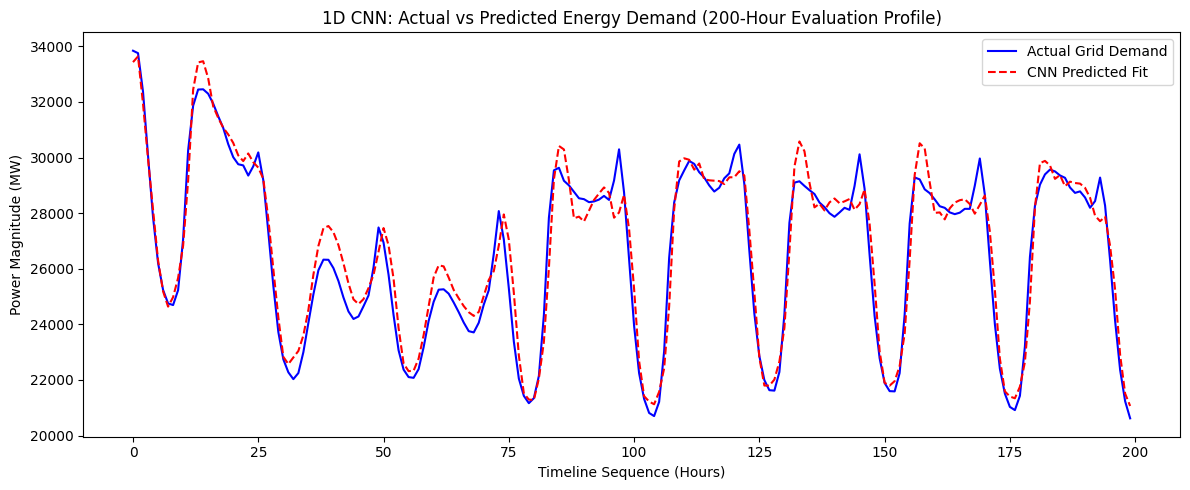

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:200], label='Actual Grid Demand', color='blue')
plt.plot(preds_actual[:200], label='CNN Predicted Fit', color='red', linestyle='dashed')
plt.title('1D CNN: Actual vs Predicted Energy Demand (200-Hour Evaluation Profile)')
plt.xlabel('Timeline Sequence (Hours)')
plt.ylabel('Power Magnitude (MW)')
plt.legend()
plt.tight_layout()
plt.show()